# Importing Libraries

In [1]:
# data sourcing : reading the files from OS directories
import os

# data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np 
import pandas as pd
import math

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Manupulaiton
from sklearn.preprocessing import LabelEncoder,StandardScaler

# Linear Regression 
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
print('Libraries Imported Successfully !!!..........')

Libraries Imported Successfully !!!..........


## Data Sourcing

In [2]:
# get the Source Directory contents from Kaggle Datasets for "Student-Scores" Dataset
DATA_DIR = "/kaggle/input/my-student-scores/"
print('List of contents in the directory : ',os.listdir(DATA_DIR))

List of contents in the directory :  ['sample_submission.csv', 'train.csv', 'test.csv']


In [3]:
## split the training data

# reading the train.csv file
train = pd.read_csv(f"{DATA_DIR}/train.csv")

# setting the index column as "id"
train = train.set_index('id')

# get 1 st 5 records of train data set
train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
## split the Test Data from dataset

# reading the train.csv file
test  = pd.read_csv(f"{DATA_DIR}/test.csv")

# setting the index column as "id"
test = test.set_index('id')

# printing 1 st 5 records of dataset
test.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [ ]:
## Submission Format Data
sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

## Data Description

In [ ]:
## Get the dimensions of the training Data
(rows, columns) = train.shape
print("Number of the Rows : " , rows)
print("Number of the Columns : ", columns)

In [ ]:
## List of  Column Names
col_Names = list(train.columns)
print("Column Names : ", col_Names)

In [ ]:
print("DataFrame Type : ", type(train))
print()
print('Data Frame Info : ')
print()
train.info()

In [ ]:
print("Data Frame Description : ")
train.describe()

In [ ]:
## Count Columnwise Null Values
count_col_null_vals = (
    train.isna()
         .sum()
         .sort_values(ascending=False)
         .rename_axis('Column Names')
         .reset_index(name='Null_Values')
)
print(count_col_null_vals)

### As there are no null values we need not worry about data imputation
### But we need to process the data

## Data Visualization

In [5]:
## To get Categorized Columns
def categories_cols(df):
    columns = list(df.columns)
    categorized_columns = []
    for col in columns:
        if df[col].dtype == 'object':
            categorized_columns.append(col)
    return categorized_columns

In [6]:
## get the categorical columns
cat_cols = categories_cols(train)
print("The Categorical Columns in Dataset are : " , len(cat_cols))
for col in cat_cols:
    print("{} : {}".format(cat_cols.index(col) + 1, col))

The Categorical Columns in Dataset are :  7
1 : gender
2 : course
3 : internet_access
4 : sleep_quality
5 : study_method
6 : facility_rating
7 : exam_difficulty


In [7]:
## get non-categorical columns
non_cat_cols = [col for col in train.columns if col not in cat_cols]
print("The Non-Categorical Columns are : ", len(non_cat_cols))
for col in non_cat_cols:
    print("{} : {}".format(non_cat_cols.index(col)+1,col))

The Non-Categorical Columns are :  5
1 : age
2 : study_hours
3 : class_attendance
4 : sleep_hours
5 : exam_score


In [ ]:
## To get all the object associated with the respective columns
def list_categories(df,columns):
    for col in columns:
        print('{} column has {} types : {}'.format(str(col).capitalize(), len(df[col].unique()),sorted(df[col].unique())))

In [ ]:
## get the list categories in the respective categorical columns
print("The list of categories in each categorical columns :")
print("----------")
print(list_categories(train,cat_cols))
print("----------")

In [ ]:
def charecterstics_of_non_cat_cols(df,columns):
    for col in columns:
        print("*****")
        print("{} has Mean value = {:.2f}".format(col.capitalize(), df[col].mean()))
        print("{} has Min value = {:.2f}".format(col.capitalize(), df[col].min()))
        print("{} has Max value = {:.2f}".format(col.capitalize(), df[col].max()))
        median = sum(df[col]) / len(df[col])
        print("{} has Median value = {:.2f}".format(col.capitalize(), median))
        print("*****")

In [ ]:
## get the charecterstics of numerical columns
print("Charecterstics of numerical columns")
print()
charecterstics_of_non_cat_cols(train,non_cat_cols)

## Grouping of Dataset using categories

# Uni Variate Analysis

## Group By Categorical Columns

## Grouping highest scored Students based on categorical

In [ ]:
def get_high_scoreres_by_col(df_1,col):
    ## Grouping the Highest Scored student in each course by gender and course
    high_scorers_by_col = df_1.groupby([col]).apply(lambda df : df.loc[df.exam_score.idxmax()],include_groups=False)
    return high_scorers_by_col

## Grouping least scored Students based on categorical

In [ ]:
def get_least_scoreres_by_col(df_1,col):
    ## Grouping the Highest Scored student in each course by gender and course
    least_scorers_by_col = df_1.groupby([col]).apply(lambda df : df.loc[df.exam_score.idxmin()],include_groups=False)
    return least_scorers_by_col 

## Creating dictinary of df's grouping for categorical colummns

In [ ]:
def dictionary_groups(df,columns):   
    cat_dict = dict()
    for col in columns:
        if col not in cat_dict:
            cat_dict[col] = {}
            cat_dict[col]['highest'] = get_high_scoreres_by_col(df,col)
            cat_dict[col]['lowest'] = get_least_scoreres_by_col(df,col)
    return cat_dict

In [ ]:
print("Grouping the highest and least scored student details into a dictionary...")
dict_cat = dictionary_groups(train,cat_cols)
print("")

### Example for Gender clause

In [ ]:
print("Highest Scored Student details by gender")
dict_cat['gender']['highest']

In [ ]:
print("Least Scored Student details by gender")
dict_cat['gender']['lowest']

# Bi Variate Analysis

In [ ]:
def groups1(*args):
    print(list(args))

In [ ]:
groups1('gender','study_hours')

In [ ]:
def get_high_scoreres_by_col(df_1,*col):    
    arr = list(col)[0]
    ## Grouping the Highest Scored student in each course by gender and course
    high_scorers_by_col = df_1.groupby(arr).apply(lambda df : df.loc[df.exam_score.idxmax()],include_groups=False)
    return high_scorers_by_col

In [ ]:
def get_least_scoreres_by_col(df_1,*col):
    arr = list(col)[0]
    ## Grouping the Highest Scored student in each course by gender and course
    least_scorers_by_col = df_1.groupby(arr).apply(lambda df : df.loc[df.exam_score.idxmin()],include_groups=False)
    return least_scorers_by_col 

In [ ]:
failure_df = pd.DataFrame(get_least_scoreres_by_col(train,cat_cols))

In [ ]:
success_df = pd.DataFrame(get_high_scoreres_by_col(train,cat_cols))

In [ ]:
failure_df.to_csv('failure.csv')

In [ ]:
success_df.to_csv('success.csv')

## Data Visualization

In [ ]:
def plot_pie(df,col,ax):
    category = train[col].unique()
    cat_count = [len(train[train[col] == cat]) for cat in category]    
    ax.pie(cat_count,labels = category,autopct = '%1.1f%%')
    ax.set_title('Pie Chart Distribution of {}'.format(col))
    

In [ ]:
def plot_bar(df,col,ax):
    sf = df[cols].value_counts().reset_index()
    sf.columns = [cols,'No. of Students']
    
    ax.bar(sf[cols], sf['No. of Students'])
    ax.set_title('Bar Charts of {}'.format(cols.capitalize()))

In [ ]:
fig, ax = plt.subplots(4,2, figsize=(10,10))

for i, cols in enumerate(cat_cols):
    r = i // 2
    c = i % 2

    plot_pie(train,cols,ax[r,c])

total_plots = 4 * 2
for j in range(len(cat_cols), total_plots):
    r = j // 2
    c = j % 2
    ax[r, c].axis('off')
    
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(4,2, figsize=(10,10))

for i, cols in enumerate(cat_cols):
    r = i // 2
    c = i % 2
    plot_bar(train,cols,ax[r,c])

total_plots = 4 * 2
for j in range(len(cat_cols), total_plots):
    r = j // 2
    c = j % 2
    ax[r, c].axis('off')

plt.tight_layout()
plt.show()

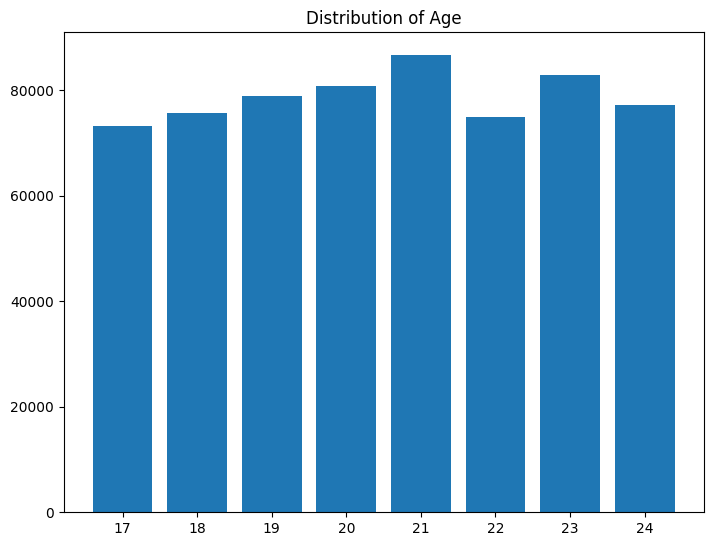

In [8]:
# This is the outlier in the Non Categorical Column
age_ind = non_cat_cols.index('age')
non_cat_cols.pop(age_ind)
fig2 = plt.figure()
ax2 = fig2.add_axes([0,0,1,1])
ages = list(map(int,train['age'].unique()))
age_counts = [len(train[train['age'] == cat]) for cat in ages]
ax2.bar(ages,age_counts)
ax2.set_title('Distribution of {}'.format('Age'))
plt.show()

In [ ]:
def plot_dist(df,col,ax):    
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

In [ ]:
def plot_box(df,col,ax):
    sns.boxplot(data = df, x = col , ax = ax)
    ax.set_title('Box Charts of {}'.format(cols.capitalize()))

In [ ]:
fig, ax = plt.subplots(3,2, figsize=(10,10))

for i, cols in enumerate(non_cat_cols):
    r = i // 2
    c = i % 2
    plot_box(train,cols,ax[r,c])

total_plots = 3 * 2
for j in range(len(non_cat_cols), total_plots):
    r = j // 2
    c = j % 2
    ax[r, c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
n = len(non_cat_cols)
cols = 2
rows = math.ceil(n / cols)

fig = plt.figure(figsize=(10, 10))

for i, col in enumerate(non_cat_cols):
    ax = fig.add_subplot(rows, cols, i+1)
    plot_dist(train,col,ax)

plt.tight_layout()
plt.show()

In [ ]:
def plot_line(df,col,ax):
    sns.lineplot(y = col, x = 'exam_score', data = df)
    ax.set_title('Line-Plot of {} vs exam_scores'.format(col))

In [ ]:
n = len(non_cat_cols)
cols = 2
rows = math.ceil(n / cols)

fig = plt.figure(figsize=(10, 10))

for i, col in enumerate(non_cat_cols):
    if col == 'exam_score':
        continue
    ax = fig.add_subplot(rows, cols, i+1)
    plot_line(train,col,ax)

plt.tight_layout()
plt.show()

## Data Manpulation

## Labeling Categorical Columns Using Label Encoder

In [9]:
def labeling_cat_cols(df,cat_cols):
    for col in cat_cols:
        d = dict()
        for i,val in enumerate(list(df[col].unique())):
            d[val] = i
        print('Labeling of {} Column : {}'.format(col,d))

In [10]:
def enable_labelEncoder():
    return LabelEncoder()

In [11]:
def catCol_transformation(df,col,le):
    df[col] = le.fit_transform(df[col])
    return df

In [12]:
print('Labeling of each categorical columns')
labeling_cat_cols(train,cat_cols)

Labeling of each categorical columns
Labeling of gender Column : {'female': 0, 'other': 1, 'male': 2}
Labeling of course Column : {'b.sc': 0, 'diploma': 1, 'bca': 2, 'b.com': 3, 'ba': 4, 'bba': 5, 'b.tech': 6}
Labeling of internet_access Column : {'no': 0, 'yes': 1}
Labeling of sleep_quality Column : {'average': 0, 'poor': 1, 'good': 2}
Labeling of study_method Column : {'online videos': 0, 'self-study': 1, 'coaching': 2, 'group study': 3, 'mixed': 4}
Labeling of facility_rating Column : {'low': 0, 'medium': 1, 'high': 2}
Labeling of exam_difficulty Column : {'easy': 0, 'moderate': 1, 'hard': 2}


In [13]:
le = enable_labelEncoder()

for cat in cat_cols:
    train = catCol_transformation(train,cat,le)

train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,78.3
1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,46.7
2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,99.0
3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,63.9
4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,100.0


## Data Scaling

In [ ]:
def check_for_outliers(df,col):
    sh = df[col]        
    Q1 = np.percentile(sh, 25)
    Q3 = np.percentile(sh, 75)
    IQR = Q3 - Q1    
    upper_bound = Q3 + 1.5 * IQR
    outliers = sh[sh > upper_bound]
    print("Mean : ", np.mean(sh))
    print("Median : " , np.median(sh))
    print("Max : ",np.max(sh))
    print("95th Percentile : ", np.percentile(sh,95))
    print("99th Percentile : ", np.percentile(sh,99))
    print("Outliers:", outliers)

In [ ]:
def data_scaling_10(df,col):
    df[col] = (df.loc[:,col] / max(df[col]) ) * 10
    return df

In [ ]:
for cat in non_cat_cols:
    if max(train[cat]) > 10 and cat not in ['exam_score','age']:
        train = data_scaling_10(train,cat)

In [ ]:
for cat in non_cat_cols:
    print('------------')
    print('Checking the outliers for {} column '. format(cat.capitalize()))
    check_for_outliers(train,cat)
    print('------------')

In [ ]:
# train['study_efficiency'] = ((train['sleep_hours'] + 1)) * 10

In [14]:
def enable_StandardScaler():
    return StandardScaler()

In [15]:
def convert_to_zscore_normalization(df,col,sc):
    return sc.fit_transform(df[[col]])

In [16]:
sc = enable_StandardScaler()
for cat in non_cat_cols:
    if cat in ['exam_score']:
        continue

    train[cat] = convert_to_zscore_normalization(train,cat,sc)

In [17]:
train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,0,1,1.655875,1.538302,0,-1.245269,0,3,1,0,78.3
1,18,2,6,0.401573,1.308814,1,-1.359895,2,4,2,2,46.7
2,20,0,1,0.287160,1.182595,1,-0.729454,2,0,0,2,99.0
3,19,1,1,-0.848492,-1.290141,1,0.703367,0,1,0,2,63.9
4,23,1,5,1.545699,0.855575,1,1.448434,1,4,0,0,100.0


In [ ]:
# exam_score = train.exam_score
# train = train.drop('exam_score',axis = 1)
# train['exam_score'] = exam_score

In [ ]:
train.head()

## Ploting the Correlation Plot

In [ ]:
corr = train.corr().round(2)
plt.figure(figsize=(10, 10)) 
sns.heatmap(corr, annot=True, cmap="coolwarm", )
plt.show()

In [ ]:
def correleated_cols(corr):
    positive_corr = []
    negative_corr = []
    
    for cat in train.columns:
        corr_cat = corr['exam_score'][cat]
        if abs(corr_cat) >= 0.01:
            if corr_cat > 0:
                positive_corr.append(cat)
            else:
                negative_corr.append(cat)
    return positive_corr,negative_corr

In [ ]:
pos_corr,neg_corr = correleated_cols(corr)

print('Posititvely Correlated Columns are : ', pos_corr)
print('Negatitvely Correlated Columns are : ', neg_corr) 

In [ ]:
least_correlated_cols = [cat for cat in train.columns if cat not in pos_corr and cat not in neg_corr]
least_correlated_cols

## Droping Least Correlated Column

In [ ]:
train = train.drop(least_correlated_cols,axis = 1)

In [ ]:
corr1 = train.corr().round(2)
sns.heatmap(data = corr1,annot = True, cmap = 'cool')

# Train Test spliting for training the model

In [19]:
# splitting the dataset into 75% training set and 25 % validation set
X = train.iloc[:,:-1]
y = train['exam_score']
X_train,X_val,y_train,y_val = train_test_split(X, y, test_size=0.25, random_state=42) 

print("No of Records in Original set : " , len(train))
print("No of Records in Training Set : " ,len(X_train))
print("No of Records in Validation Set :"  ,  len(X_val))

No of Records in Original set :  630000
No of Records in Training Set :  472500
No of Records in Validation Set : 157500


In [ ]:
print("Shape of training data : ", X_train.shape)
print("Shape of validation data : ", X_val.shape)

## Model Training

# Linear Regression Model

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model.fit(X_train,y_train)

In [ ]:
lr_model.get_params(deep=True)

In [ ]:
lr_model.coef_

In [ ]:
lr_model.intercept_

In [ ]:
y_pred = lr_model.predict(X_val)

In [ ]:
mse = mean_squared_error(y_pred,y_val)
mse

In [ ]:
r = r2_score(y_pred,y_val)
r

In [ ]:
RMSE = np.sqrt(mse)
RMSE

In [ ]:
l_model = Lasso()

In [ ]:
l_model.fit(X_train,y_train)

In [ ]:
l_model.coef_

In [ ]:
l_model.intercept_

In [ ]:
yl_pred = l_model.predict(X_val)

In [ ]:
msel = mean_squared_error(yl_pred,y_val)
msel

In [ ]:
rmsel = np.sqrt(msel)
rmsel

In [ ]:
r2l = r2_score(yl_pred,y_val)
r2l

## Building Regression Model

In [ ]:
# y = np.dot(w,x) + b

In [20]:
features = X_train
features.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
103127,21,2,2,0.304110,1.268654,1,1.104557,1,4,0,0
278370,21,1,2,-1.043417,-1.106550,0,-0.729454,2,2,0,2
314039,18,0,0,0.261735,0.190059,1,1.161870,0,0,2,2
255610,19,1,6,-0.496779,0.993268,1,-1.703772,2,1,1,0
602921,19,1,2,0.333773,-0.900011,1,1.620373,2,2,2,1


In [21]:
target = y_train
target.head()

id
103127    80.4
278370    37.0
314039    63.2
255610    50.0
602921    70.5
Name: exam_score, dtype: float64

In [22]:
features.shape

(472500, 11)

In [23]:
def linear_experssion_for_model(f):
    (x,y) = f.shape
    w = np.zeros(y)
    b = np.zeros(y)
    exp = ''
    for i in range(1,y+1):
        exp = exp + 'w{}.x{}'.format(i,i) + ' + '
    return exp[:-2] + '+ b'

In [24]:
e = linear_experssion_for_model(features)
print('f(x) = {}'.format(e))

f(x) = w1.x1 + w2.x2 + w3.x3 + w4.x4 + w5.x5 + w6.x6 + w7.x7 + w8.x8 + w9.x9 + w10.x10 + w11.x11 + b


In [25]:
def initialize_parameters(f):
    (x,y) = f.shape
    w = np.zeros(y)
    b = 0
    return w,b

In [26]:
w_n,b_n = initialize_parameters(features)
print('Weights : ' , w_n)
print('Weights shape : ', w_n.shape)
print('Bias : ', b_n)

Weights :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Weights shape :  (11,)
Bias :  0


In [27]:
def model_func(x,w,b):
    f = np.dot(x,w_n) + b
    return f

In [28]:
def cost_func(f,y):
    (m,) = f.shape
    J = (1 / (2 * m))
    diff_sum = np.sum(np.square(f - y))
    J = J * diff_sum
    return J    

In [29]:
def update_parameters(x,y,w,b,alpha):
    (m,n) = x.shape
    f = model_func(x,w,b)
    w_update = (alpha / m) * np.sum(np.dot(np.transpose(x),( f - y )))
    b_update = (alpha / m) * (np.sum(f - y))
    w = w - w_update
    b = b - b_update
    return w,b

In [30]:
def minimizing_cost(x, y, w, b, alpha, iterations, tol=1e-6):
    prev_cost = float('inf')
    
    for i in range(iterations):
        w, b = update_parameters(x, y, w, b, alpha)
        
        f = model_func(x, w, b)
        cost_J = cost_func(f, y)
        
        if abs(prev_cost - cost_J) < tol:
            break
        
        prev_cost = cost_J
        print('{} Iteration cost value : {}'.format(i+1,prev_cost))
    
    return w, b

In [ ]:
w_new,b_new = minimizing_cost(features,target,w_n,b_n,0.001,10)

In [ ]:
w_new